# 01 — Fairness Metrics Evaluation (Reusable Package)

This notebook shows how to evaluate bias metrics on `data/train.csv` using `fairness_jigsaw.metrics`.

`fairness_jigsaw.metrics.bias` is **model-agnostic**: it only depends on the score column and identity columns, so the same evaluation pipeline can be reused for different models in later experiments.

In [1]:
!uv pip install -e ..

Using Python 3.14.0 environment at: /Users/albert/Desktop/AI-Fairness-Jigsaw/.venv
Resolved 107 packages in 295ms                                       
   Building fairness-jigsaw @ file:///Users/albert/Desktop/AI-Fairness-Jigsaw
   Building fairness-jigsaw @ file:///Users/albert/Desktop/AI-Fairness-Jigsaw
   Building fairness-jigsaw @ file:///Users/albert/Desktop/AI-Fairness-Jigsaw
   Building fairness-jigsaw @ file:///Users/albert/Desktop/AI-Fairness-Jigsaw
      Built fairness-jigsaw @ file:///Users/albert/Desktop/AI-Fairness-Jigsaw
Prepared 1 package in 793ms                                              
Uninstalled 1 package in 1ms
Installed 1 package in 2ms1.0 (from file:///Users/albert/Des
 ~ fairness-jigsaw==0.1.0 (from file:///Users/albert/Desktop/AI-Fairness-Jigsaw)


In [2]:
from pathlib import Path
import sys

import pandas as pd

from fairness_jigsaw.metrics import DEFAULT_IDENTITY_COLUMNS, FairnessBiasEvaluator


In [3]:
USE_COLS = ['id', 'target'] + DEFAULT_IDENTITY_COLUMNS
TOXICITY_THRESHOLD = 0.5

df = pd.read_csv('../data/train.csv', usecols=USE_COLS)
df['toxic'] = (df['target'] >= TOXICITY_THRESHOLD).astype(int)
print(f'Loaded {len(df):,} rows with {len(DEFAULT_IDENTITY_COLUMNS)} identity columns.')

Loaded 1,804,874 rows with 24 identity columns.


In [4]:
df

,id,target,asian,atheist,bisexual,black,buddhist,christian,female,heterosexual,...,other_disability,other_gender,other_race_or_ethnicity,other_religion,other_sexual_orientation,physical_disability,psychiatric_or_mental_illness,transgender,white,toxic
0,59848,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,59849,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,59852,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,59855,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,59856,0.893617,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1804869,6333967,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1804870,6333969,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1804871,6333982,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1804872,6334009,0.621212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [5]:
evaluator = FairnessBiasEvaluator(
    identity_cols=DEFAULT_IDENTITY_COLUMNS,
    toxicity_threshold=TOXICITY_THRESHOLD,
    identity_threshold=0.5,
)

raw_table, detail_tables = evaluator.evaluate(
    df,
    score_col='target',
    label_col='toxic',
)

normalized_table = evaluator.build_bias_metrics_table(normalize=True)

In [6]:
# Final multi-metric fairness table (normalized: 0=least biased, 1=most biased)
normalized_table.round(3)

,DP Gap,1-Subgroup AUC,1-BPSN AUC,1-BNSP AUC,1-Pinned AUC,KS Statistic,|Mean Diff|,Wasserstein-1,KL Divergence,|Partial r|
identity,,,,,,,,,,
black,1.000,0.0,0.0,0.0,0.0,1.000,1.000,1.000,1.000,0.710
white,0.853,0.0,0.0,0.0,0.0,0.973,0.917,0.917,0.921,1.000
homosexual_gay_or_lesbian,0.867,0.0,0.0,0.0,0.0,0.991,0.924,0.924,0.955,0.737
muslim,0.620,0.0,0.0,0.0,0.0,0.830,0.718,0.716,0.637,0.861
heterosexual,0.621,0.0,0.0,0.0,0.0,0.910,0.738,0.738,0.831,0.025
transgender,0.555,0.0,0.0,0.0,0.0,0.782,0.655,0.653,0.591,0.186
bisexual,0.569,0.0,0.0,0.0,0.0,0.821,0.637,0.642,0.704,0.030
psychiatric_or_mental_illness,0.545,0.0,0.0,0.0,0.0,0.549,0.539,0.536,0.249,0.367
other_disability,0.498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000


(<Figure size 1400x1000 with 2 Axes>,
 <Axes: title={'center': 'Fairness Bias Heatmap'}, xlabel='Metric', ylabel='Identity subgroup'>)

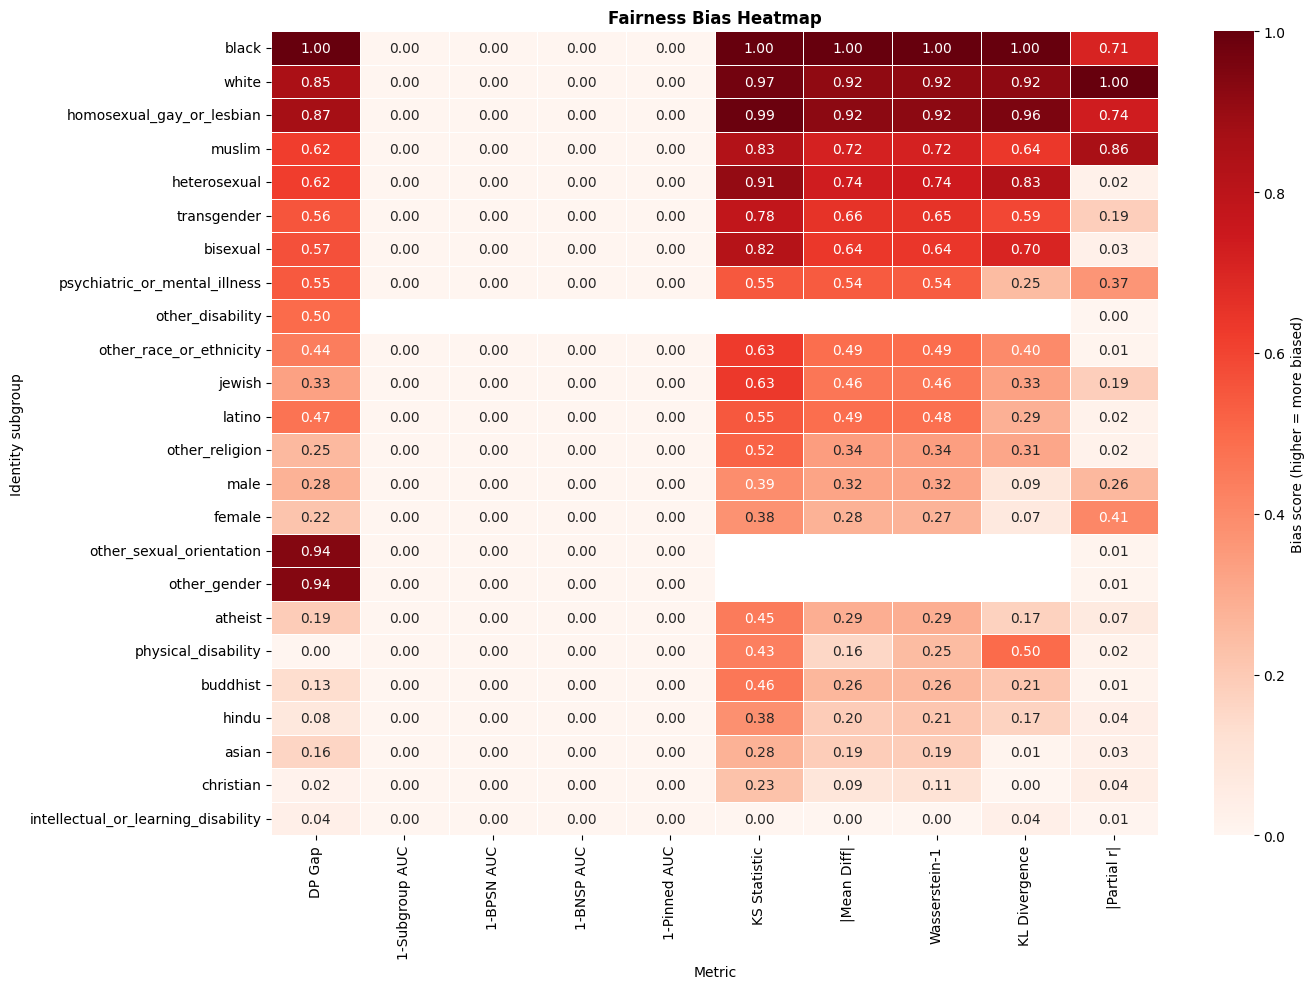

In [7]:
evaluator.plot_bias_heatmap(normalized_table)

In [8]:
# Optional: save result for downstream tasks
output_path = '../data/fairness_bias_metrics_table.csv'
normalized_table.to_csv(output_path)
print(f'Saved table to: {output_path}')

Saved table to: ../data/fairness_bias_metrics_table.csv
